In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("C:/Users/DBDA52/Downloads/k_circle_sales.csv")

In [31]:
df.shape

(8523, 13)

In [32]:
print(df.dtypes)

Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
Profit                       float64
dtype: object


In [33]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales', 'Profit'],
      dtype='str')

In [34]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
count,7774.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,11.676740,0.066132,140.998838,1997.831867,2181.288914,13.414514
std,5.776851,0.051598,62.258099,8.371760,1706.499616,1.701840
min,0.000000,0.000000,31.300000,1985.000000,33.290000,0.100000
25%,7.720000,0.026989,93.800000,1987.000000,834.247400,13.150000
50%,11.800000,0.053931,142.700000,1999.000000,1794.331000,13.900000
75%,16.500000,0.094585,185.650000,2004.000000,3101.296400,14.300000
max,21.350000,0.328391,266.900000,2009.000000,13086.964800,24.000000


In [35]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,NaN,NaN,Grocery Store,732.3800,13.6
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1


In [36]:
df.dropna(inplace=True)

In [ ]:
df['Outlet_Location_Type'].fillna(
    df['Outlet_Location_Type'].mode()[0],
    inplace=True
)

C:\Users\DBDA52\AppData\Local\Temp\ipykernel_14676\3476993068.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Outlet_Location_Type'].fillna(


0       Tier 2
1       Tier 2
2       Tier 2
4       Tier 3
5       Tier 2
         ...  
8517     Tier1
8518    Tier 3
8520     Tier1
8521    Tier 2
8522     Tier1
Name: Outlet_Location_Type, Length: 5364, dtype: str

In [38]:
print(df['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    3192
Regular    1828
LF          204
reg          76
low fat      64
Name: count, dtype: int64


In [39]:
print(df['Item_MRP'].unique())

[249.8  48.3 141.6 ...  51.8  99.1 214.5]


In [40]:
df.replace(to_replace='LF', value="Low Fat", inplace=True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
4,NCD19,8.930,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4,OUT018,2009,Medium,Tier 2,Supermarket Type2,556.6088,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8517,FDF53,20.750,reg,0.083607,Frozen Foods,178.8,OUT046,1997,Small,Tier1,Supermarket Type1,3608.6360,13.2
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,14.1
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1,OUT035,2004,Small,Tier1,Supermarket Type1,1193.1136,9.5
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1,OUT018,2009,Medium,Tier 2,Supermarket Type2,1845.5976,14.2


In [41]:
df.replace(to_replace="reg", value="Regular", inplace=True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
4,NCD19,8.930,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4,OUT018,2009,Medium,Tier 2,Supermarket Type2,556.6088,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8517,FDF53,20.750,Regular,0.083607,Frozen Foods,178.8,OUT046,1997,Small,Tier1,Supermarket Type1,3608.6360,13.2
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,14.1
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1,OUT035,2004,Small,Tier1,Supermarket Type1,1193.1136,9.5
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1,OUT018,2009,Medium,Tier 2,Supermarket Type2,1845.5976,14.2


In [42]:
print(df[df['Item_Type'] == 'Soft Drinks']['Item_Weight'].mean())

10.649089219330854


In [43]:
print(df[df['Profit']>10.5]['Item_Weight'].mean())

11.154208193815245


In [44]:
Q1 = df["Item_MRP"].quantile(0.25)
Q3 = df["Item_MRP"].quantile(0.75)
IQR = Q3-Q1
print(f"Q1:{Q1}, Q3:{Q3}, IQR:{IQR}")

Q1:94.3, Q3:186.4, IQR:92.10000000000001


In [45]:
percentile_30 = df["Item_MRP"].quantile(0.30)
print(f"30th Percentile of Item_MRP: {percentile_30}")

30th Percentile of Item_MRP: 102.4


In [46]:
df['Item_Weight'].var()
df.var(numeric_only=True)

Item_Weight                  3.811519e+01
Item_Visibility              2.300883e-03
Item_MRP                     3.886860e+03
Outlet_Establishment_Year    7.056684e+01
Item_Outlet_Sales            2.689551e+06
Profit                       2.866716e+00
dtype: float64

In [47]:
df['Item_Weight'].std()
df.std(numeric_only=True)

Item_Weight                     6.173750
Item_Visibility                 0.047968
Item_MRP                       62.344688
Outlet_Establishment_Year       8.400407
Item_Outlet_Sales            1639.985035
Profit                          1.693138
dtype: float64

In [48]:
variance = df["Item_MRP"].var()
std_dev =  df["Item_MRP"].std()
mean_mrp = df["Item_MRP"].mean()
cv = (std_dev / mean_mrp) * 100
print(f"Variance:{variance}, standard Deviation:{std_dev}, Mean:{mean_mrp}")

Variance:3886.8601635116074, standard Deviation:62.34468833438505, Mean:141.62035794183447


In [49]:
print(df.isna().sum())

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Profit                       0
dtype: int64


In [ ]:
df['Item_Weight'].skew()
df.skew(numeric_only = True )

Item_Weight                 -0.330700
Item_Visibility              1.040709
Item_MRP                     0.126174
Outlet_Establishment_Year   -0.182002
Item_Outlet_Sales            1.108476
Profit                      -3.441224
dtype: float64

In [51]:
df['Item_Weight'].kurt()
df.kurt(numeric_only=True)

Item_Weight                  -0.800156
Item_Visibility               1.224127
Item_MRP                     -0.892812
Outlet_Establishment_Year    -1.273261
Item_Outlet_Sales             1.385059
Profit                       16.763115
dtype: float64

# Prepare a histogram for item_type

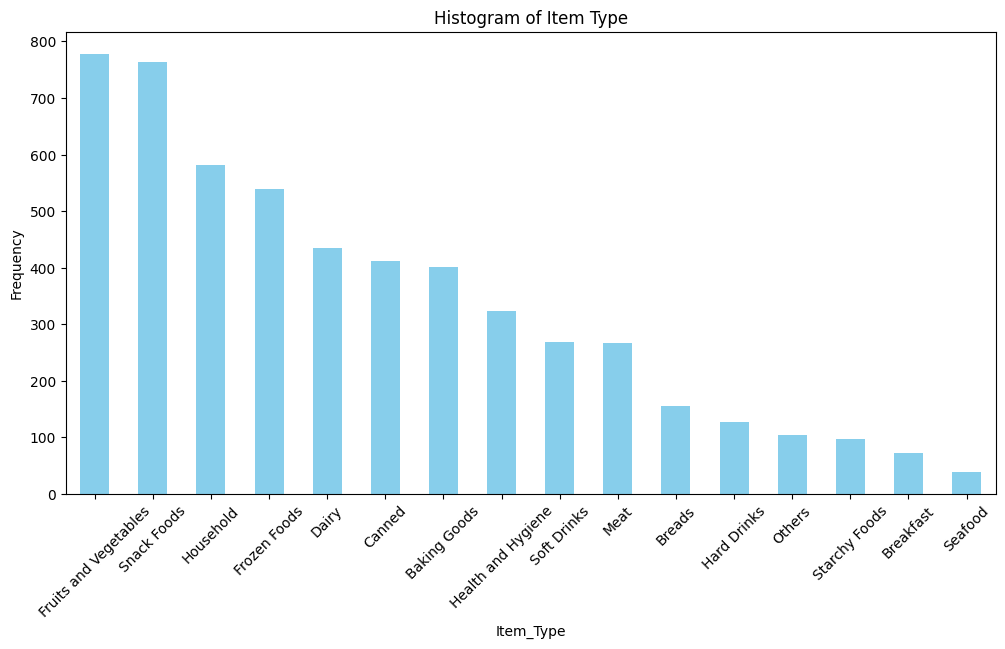

In [52]:
df["Item_Type"].value_counts().plot(kind="bar", figsize=(12,6), color="skyblue")
plt.title("Histogram of Item Type")
plt.xlabel("Item_Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [53]:
df.to_csv("updated_k_circle_sales.csv", index=False)
print("File Saved Successfully")

File Saved Successfully


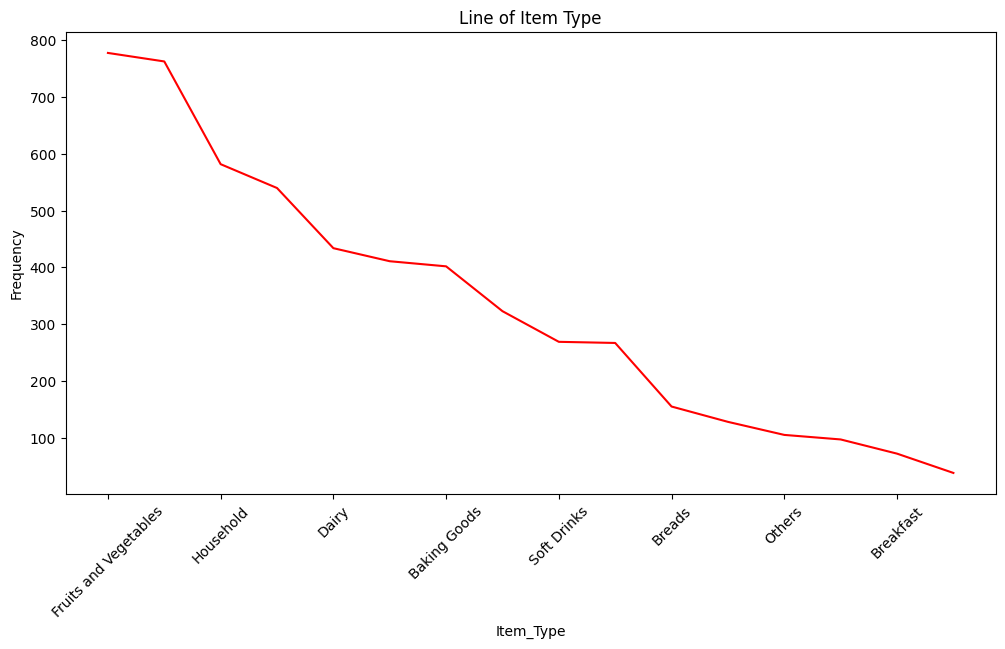

In [54]:
df["Item_Type"].value_counts().plot(kind="line", figsize=(12,6), color="red")
plt.title("Line of Item Type")
plt.xlabel("Item_Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

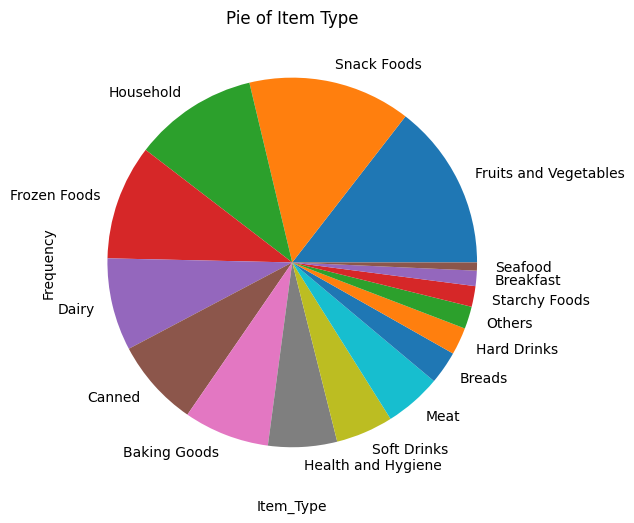

In [55]:
df["Item_Type"].value_counts().plot(kind="pie", figsize=(12,6), color="green")
plt.title("Pie of Item Type")
plt.xlabel("Item_Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

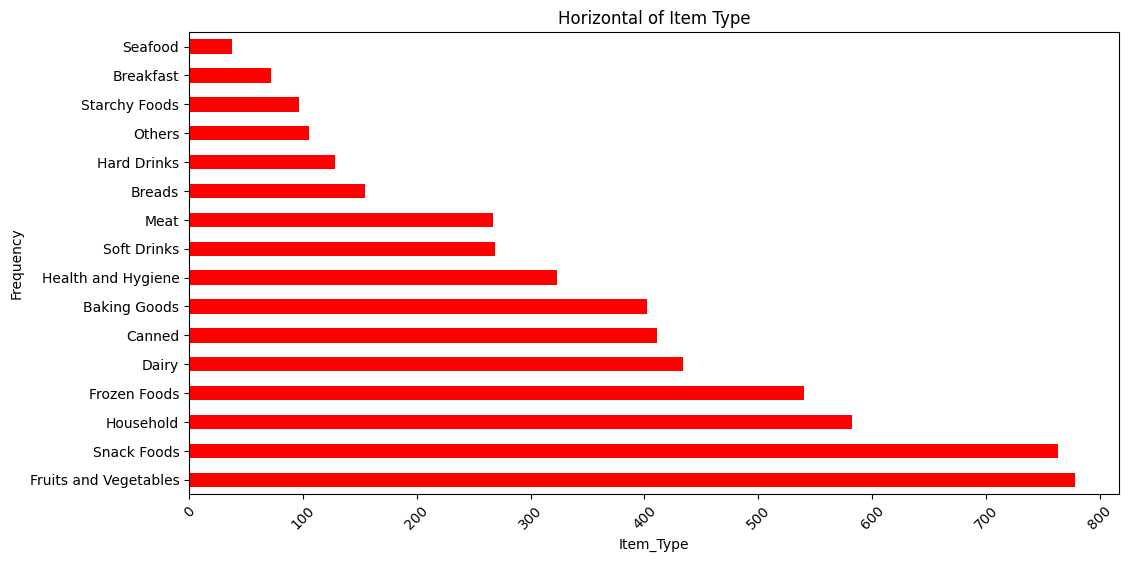

In [56]:
df["Item_Type"].value_counts().plot(kind="barh", figsize=(12,6), color="red")
plt.title("Horizontal of Item Type")
plt.xlabel("Item_Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()